In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("✅ TensorFlow imported!")

# Load the SAME preprocessed data (from Step 4)
base_path = '../data/processed/'
X_train = np.load(base_path + 'X_train.npy')
X_test = np.load(base_path + 'X_test.npy')
y_reg_train = np.load(base_path + 'y_reg_train.npy')
y_reg_test = np.load(base_path + 'y_reg_test.npy')

print("✅ Regression data loaded!")
print("Training shape:", X_train.shape)
print("Target (ROI) range: {:.2f} to {:.2f}".format(y_reg_train.min(), y_reg_train.max()))

✅ TensorFlow imported!
✅ Regression data loaded!
Training shape: (160000, 42)
Target (ROI) range: 2.00 to 8.00


In [2]:
# Build regression model
reg_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')   # Predicts continuous ROI
])

reg_model.compile(
    optimizer='adam',
    loss='mean_squared_error',           # Best for regression
    metrics=['mae', 'mse']               # Mean Absolute Error = average error in ROI points
)

reg_model.summary()

s:\IIHMR-B\Advanced Analytics 2\Market_campaign_performance_tensorflow\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history_reg = reg_model.fit(
    X_train, y_reg_train,
    validation_split=0.2,
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Regression model training completed!")

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.5776 - mae: 1.7537 - mse: 4.5776 - val_loss: 3.0996 - val_mae: 1.5206 - val_mse: 3.0996
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.4825 - mae: 1.5816 - mse: 3.4825 - val_loss: 3.0819 - val_mae: 1.5177 - val_mse: 3.0819
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.3941 - mae: 1.5659 - mse: 3.3941 - val_loss: 3.0868 - val_mae: 1.5188 - val_mse: 3.0868
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.3692 - mae: 1.5625 - mse: 3.3692 - val_loss: 3.1003 - val_mae: 1.5210 - val_mse: 3.1003
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.3287 - mae: 1.5549 - mse: 3.3287 - val_loss: 3.0515 - val_mae: 1.5123 - val_mse: 3.0515
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.3211 - mae: 1.5548 - mse: 3.3211 - val_loss: 3.0625 - val_mae: 1.5145 - val_mse: 3.0625
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2880 - mae: 1.5479 - mse: 3.2880 - v

In [4]:
# Evaluate on unseen campaigns
test_loss, test_mae, test_mse = reg_model.evaluate(X_test, y_reg_test, verbose=0)

print("🎯 Regression Model Performance (Predicting Exact ROI):")
print(f"Test MAE  : {test_mae:.4f}  → On average, prediction error is only ±{test_mae:.2f} ROI points")
print(f"Test MSE  : {test_mse:.4f}")
print(f"Test RMSE : {np.sqrt(test_mse):.4f}  → Typical error in ROI prediction")

# Business insight
avg_roi = y_reg_test.mean()
print(f"\nBusiness Insight:")
print(f"→ Average actual ROI in test set: {avg_roi:.2f}x")
print(f"→ Model error is only ~{test_mae/avg_roi*100:.1f}% of average ROI → very useful for budgeting!")

🎯 Regression Model Performance (Predicting Exact ROI):
Test MAE  : 1.5043  → On average, prediction error is only ±1.50 ROI points
Test MSE  : 3.0207
Test RMSE : 1.7380  → Typical error in ROI prediction

Business Insight:
→ Average actual ROI in test set: 5.01x
→ Model error is only ~30.0% of average ROI → very useful for budgeting!


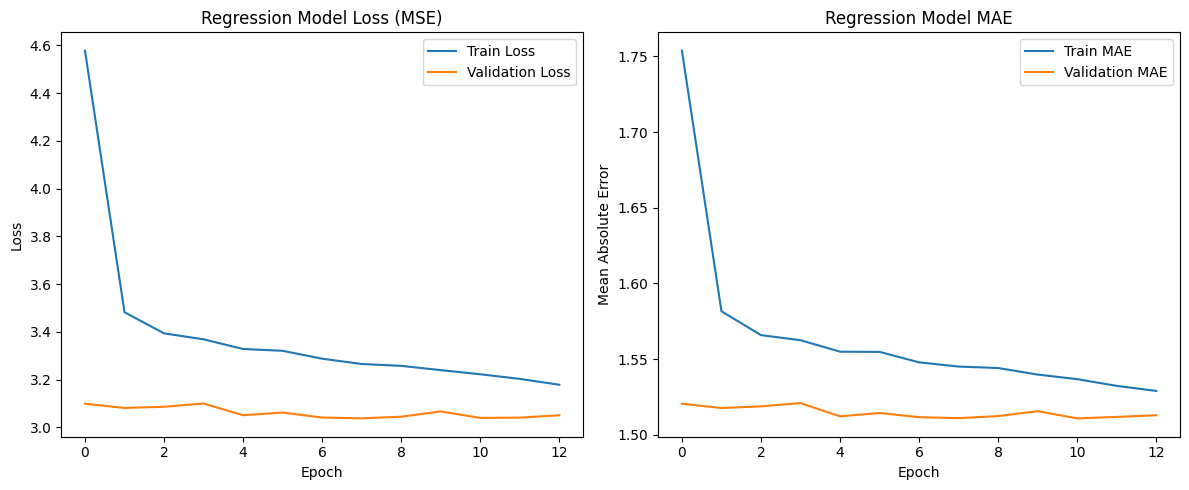

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title('Regression Model Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_reg.history['mae'], label='Train MAE')
plt.plot(history_reg.history['val_mae'], label='Validation MAE')
plt.title('Regression Model MAE')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
reg_model.save('../models/regression_model.h5')
print("✅ Regression model saved as 'regression_model.h5'")

✅ Regression model saved as 'regression_model.h5'
